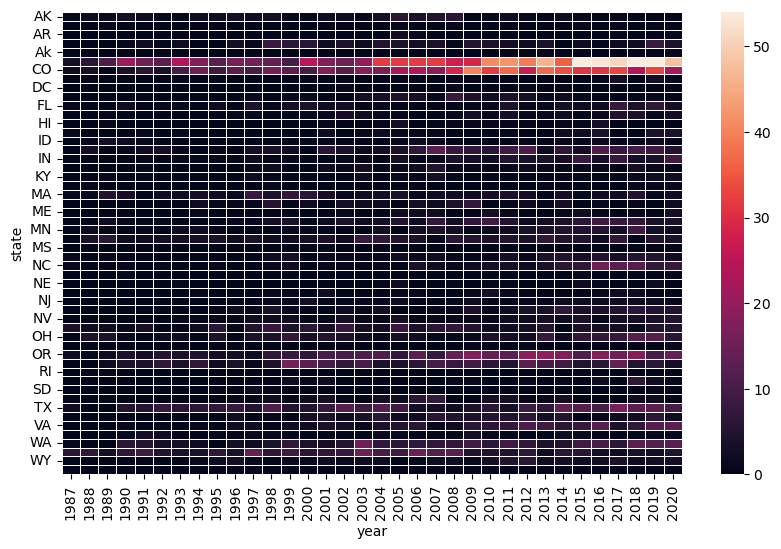

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

d = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-10-20/beer_awards.csv')

# Filter safely
filtered = d[
    (d.category.str.contains('American', na=False)) &
    (d.year >= 2014) &
    (d.year <= 2017)
]

# Group + pivot
d3 = d.groupby(['year', 'state']).size().reset_index(name='medal_count')
d4 = d3.pivot(index='state', columns='year', values='medal_count').fillna(0)

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(d4, annot=False, linewidths=.5)
plt.show()

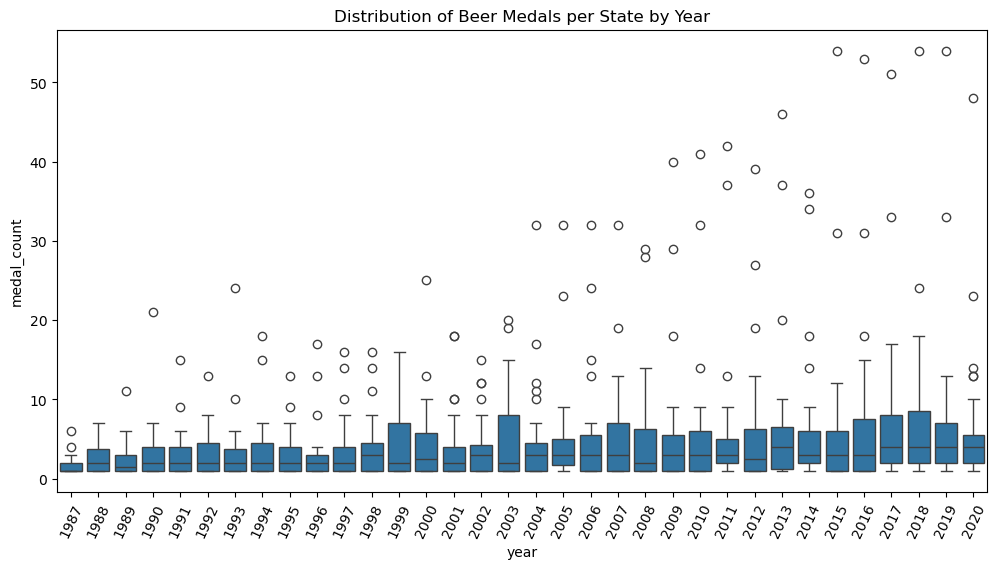

In [3]:
# Box plot
plt.figure(figsize=(12,6))
sns.boxplot(data=d3, x="year", y="medal_count")
plt.xticks(rotation=65)

plt.title("Distribution of Beer Medals per State by Year")
plt.show()